# Week 1.2 - Pressure-Velocity Coupling
## SIMPLE, PISO and PIMPLE in the Re=100 lid-driven cavity

This is an independent extension. The original Week-1 streamfunction-vorticity lab is unchanged.

[Lecture PDF](https://github.com/Ehsan-Roohi/FlowMLLab/blob/main/lectures/week01_2_pressure_velocity.pdf) | [Executed report](https://github.com/Ehsan-Roohi/FlowMLLab/blob/main/results/week01_2_pressure_velocity/README.md) | [Algorithm/source notes](https://github.com/Ehsan-Roohi/FlowMLLab/blob/main/notebooks/week01_2/README.md)

**Learning outcomes:** derive pressure correction, distinguish linear/coupling/time iterations, preserve mass, compare benchmark errors and measured cost.

**Qualified scope:** Re=100, 32 and 64 uniform cells per side, steady solutions. Startup time accuracy and larger-time-step benefits are future experiments.

In [1]:
from pathlib import Path
import os, sys, subprocess
if "google.colab" in sys.modules or os.environ.get("COLAB_RELEASE_TAG"):
    ROOT = Path("/content/FlowMLLab")
    if not (ROOT / ".git").exists():
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/Ehsan-Roohi/FlowMLLab.git", str(ROOT)], check=True)
    subprocess.run([sys.executable,"-m","pip","install","-q","-e",str(ROOT)],check=True)
else:
    ROOT = next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"flowmllab/pressure_velocity.py").exists())
sys.path.insert(0,str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from flowmllab.pressure_velocity import CavityConfig, run_cavity, pressure_matrix, divergence
from flowmllab.pressure_velocity_lab import load_results, figures, LABELS
RESULTS = ROOT / "results/week01_2_pressure_velocity"
manifest, recorded = load_results(RESULTS)
print("All recorded field hashes verified.")
print("Recorded source SHA-256:", manifest["source_sha256"])


All recorded field hashes verified.
Recorded source SHA-256: d502568afece2262dbb759c1e315e384cf9c88ac46e98992ee7950a77a0aba5d


## 1. Begin with evidence
Every selected algorithm appears below. No method is silently removed after a failure.
The recorded SIMPLE/PISO/PIMPLE runs use the same central FV momentum equations, mesh spacing and steady stopping criteria.
The streamfunction-vorticity result is an independent FD reference, with its own stopping norm.
Sparse LU is only the linear-equation solver; it is independent of SIMPLE/PISO/PIMPLE.

,method,cells/side,iterations/steps,CPU seconds,Ghia u rel L2,Ghia v rel L2,FV momentum Linf,FV divergence Linf,converged
0,SIMPLE,32,480,5.073568,0.002847,0.026867,8.538181e-08,3.219647e-15,True
1,PISO (2 corrections),32,540,6.993848,0.002847,0.026867,9.542638e-08,1.933263e-14,True
2,"PIMPLE (3 outer, 2 inner)",32,540,19.603602,0.002847,0.026867,8.635125e-08,2.126424e-14,True
3,Streamfunction-vorticity,32,19000,8.106372,0.010230,0.036958,NaN,NaN,True
4,SIMPLE,64,1870,137.987439,0.003954,0.032607,9.283927e-08,5.338611e-14,True
5,PISO (2 corrections),64,540,42.755732,0.003954,0.032607,9.491193e-08,2.842171e-14,True
6,"PIMPLE (3 outer, 2 inner)",64,540,146.522112,0.003954,0.032607,8.488696e-08,1.776357e-14,True
7,Streamfunction-vorticity,64,19000,17.284136,0.003026,0.021253,NaN,NaN,True


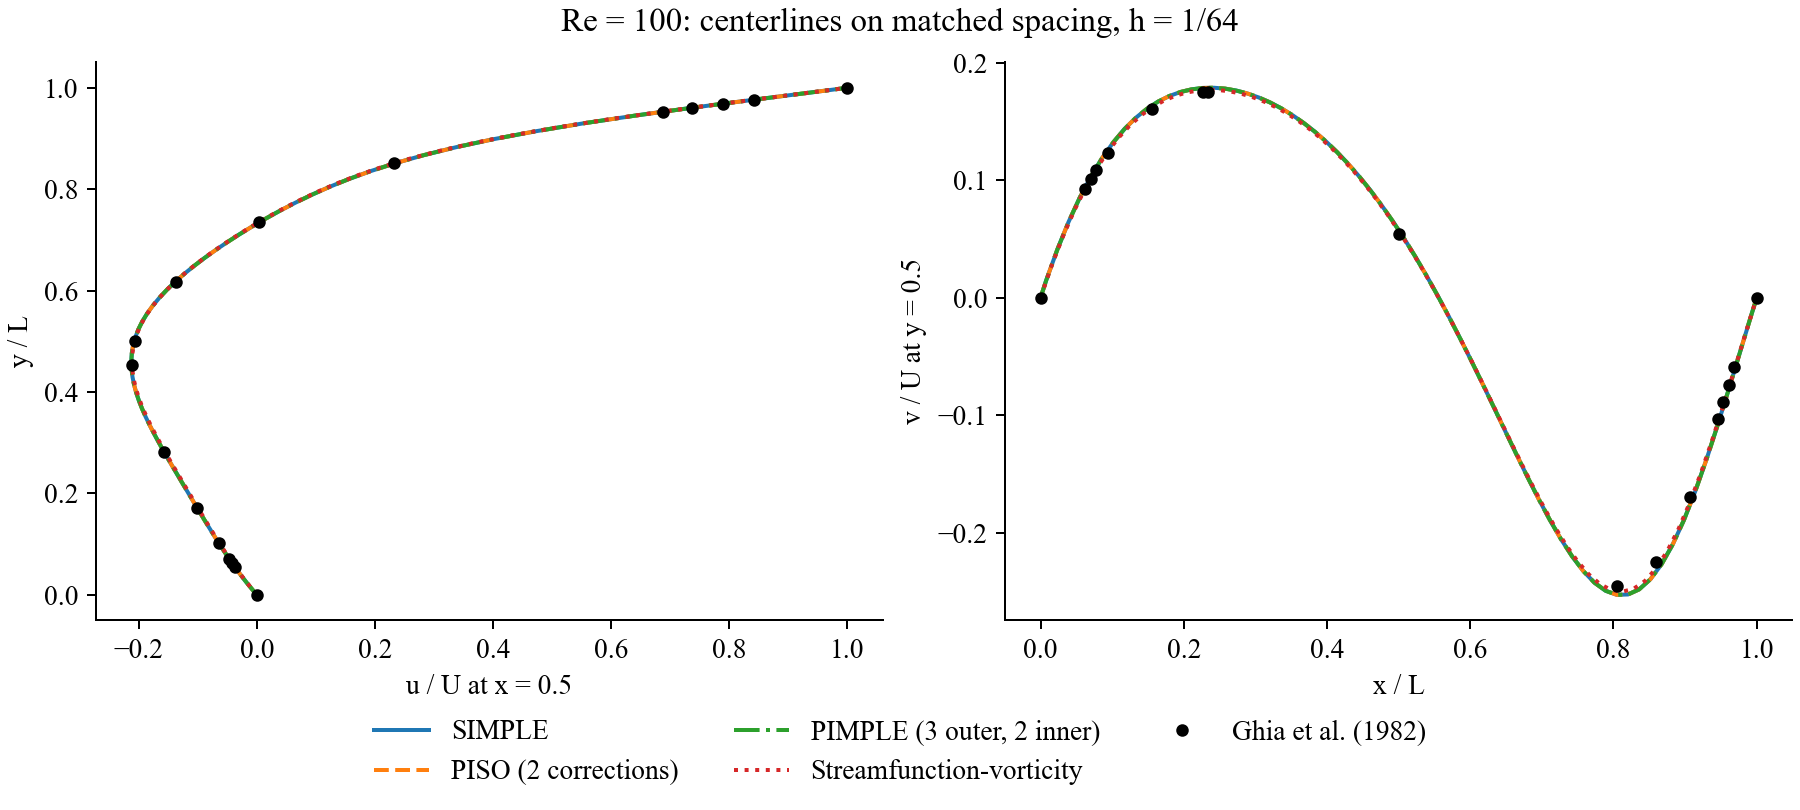

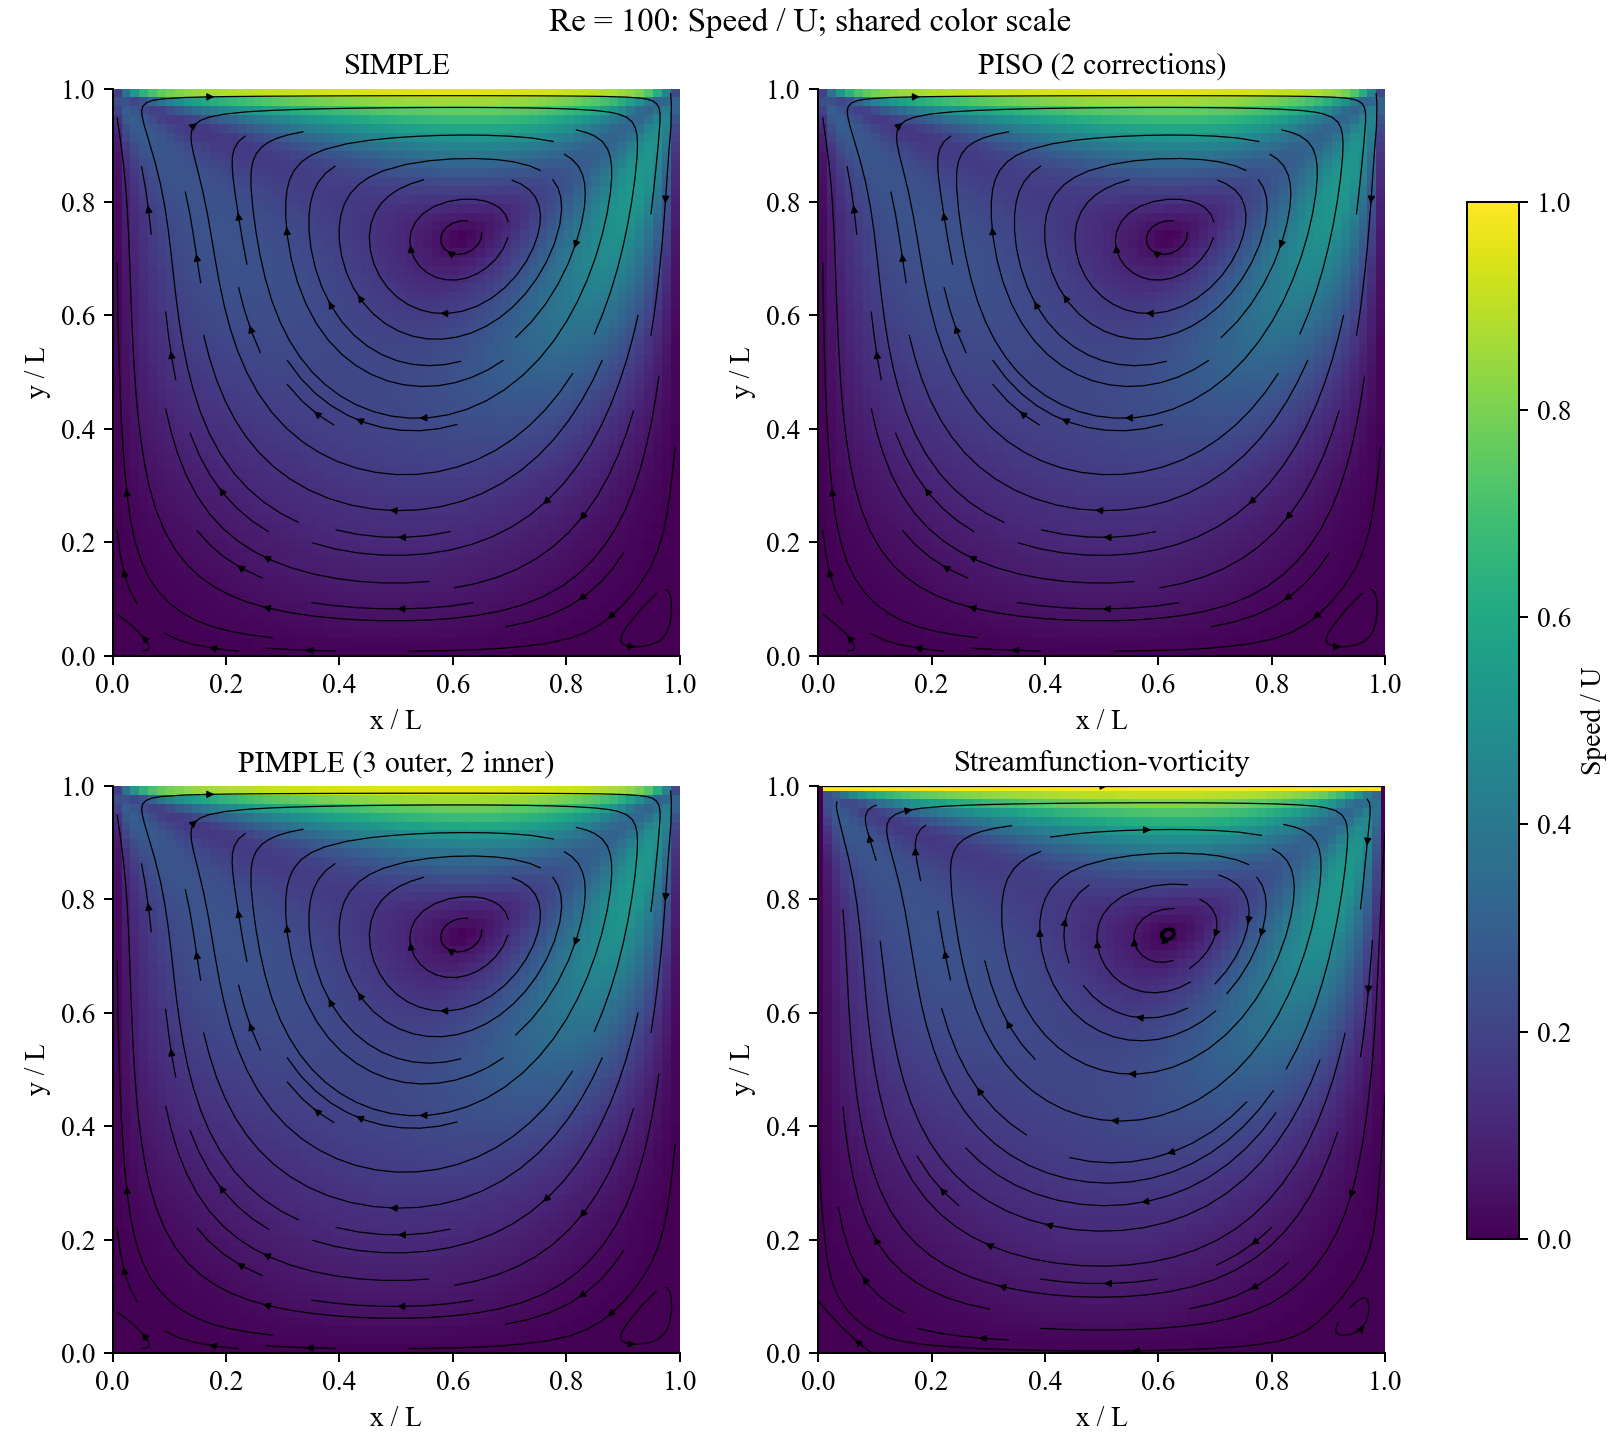

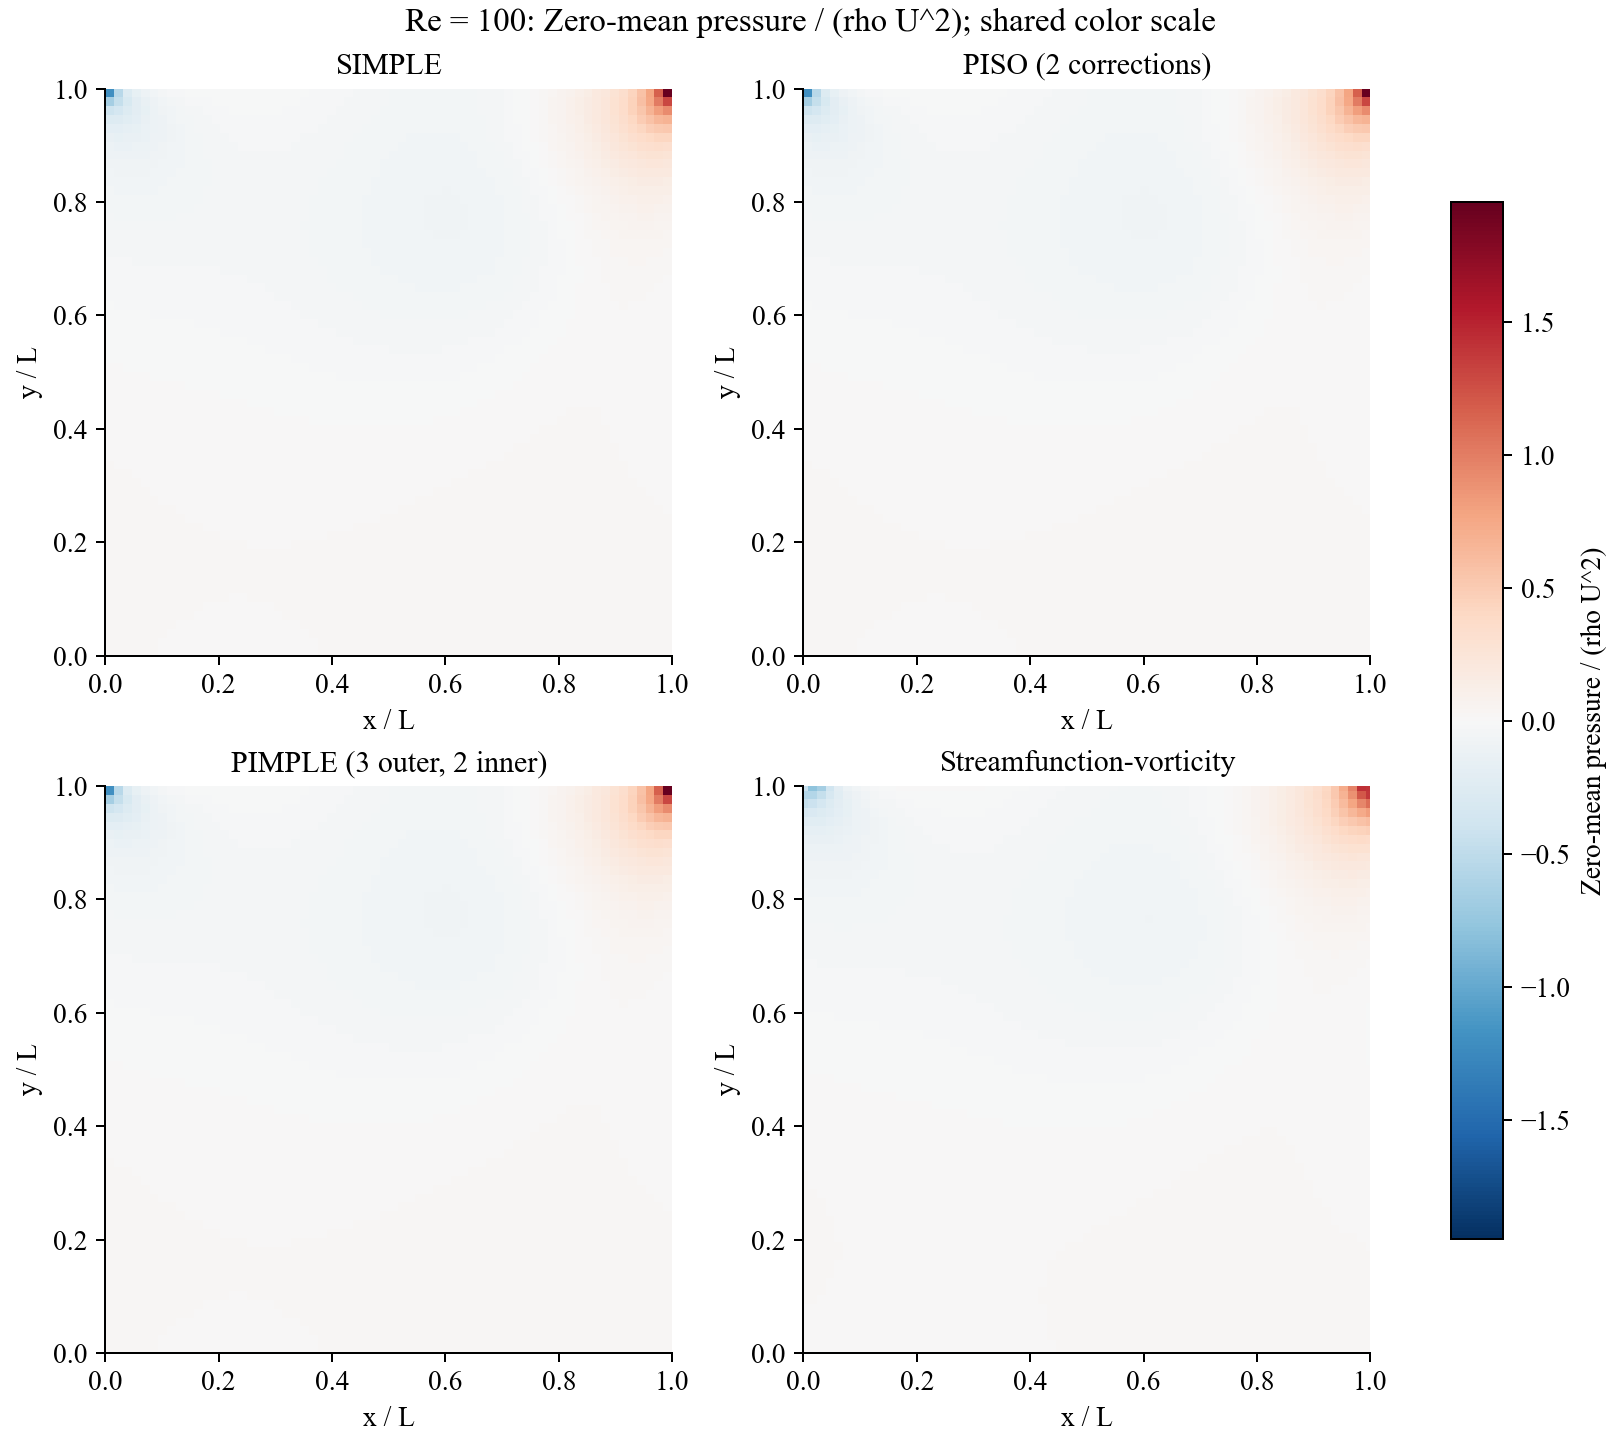

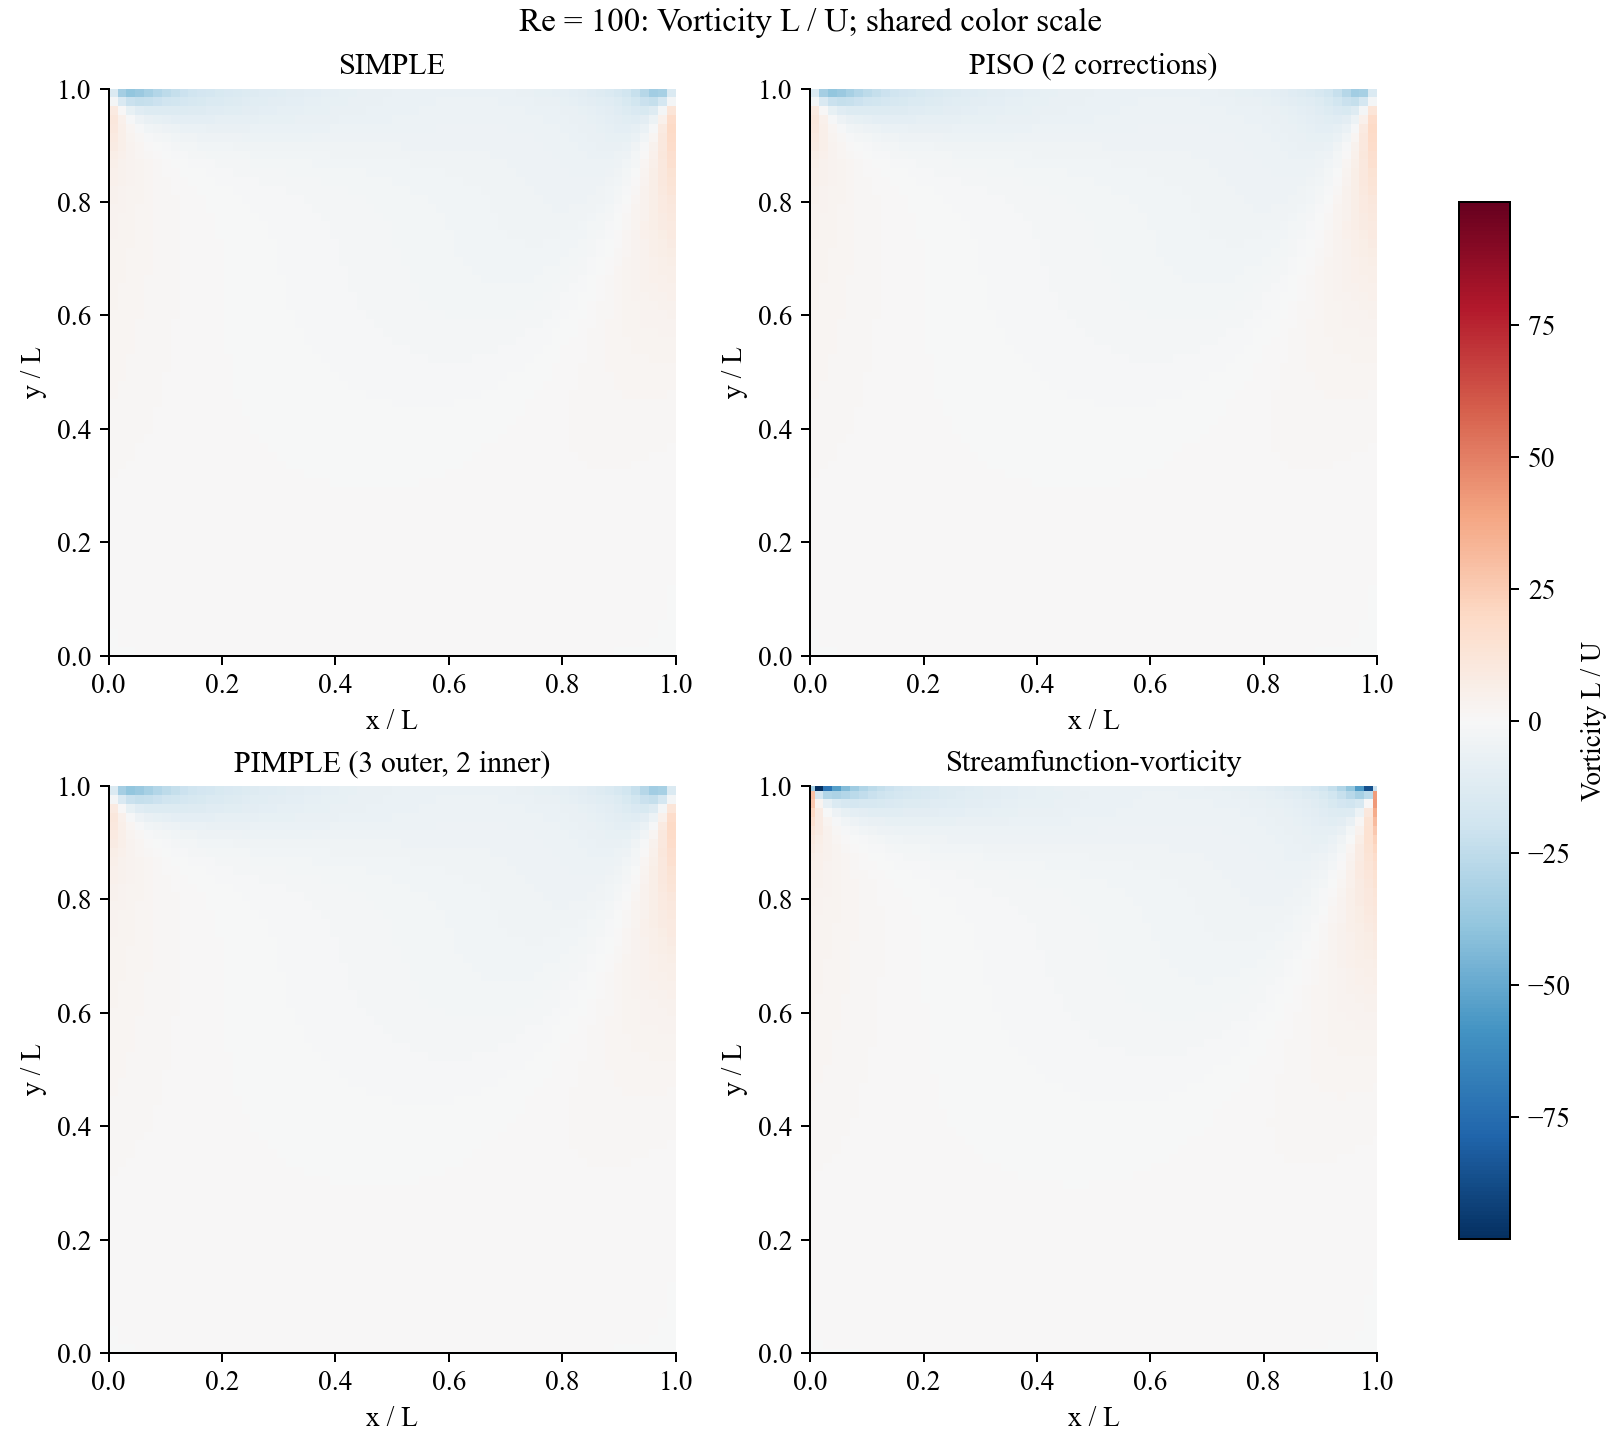

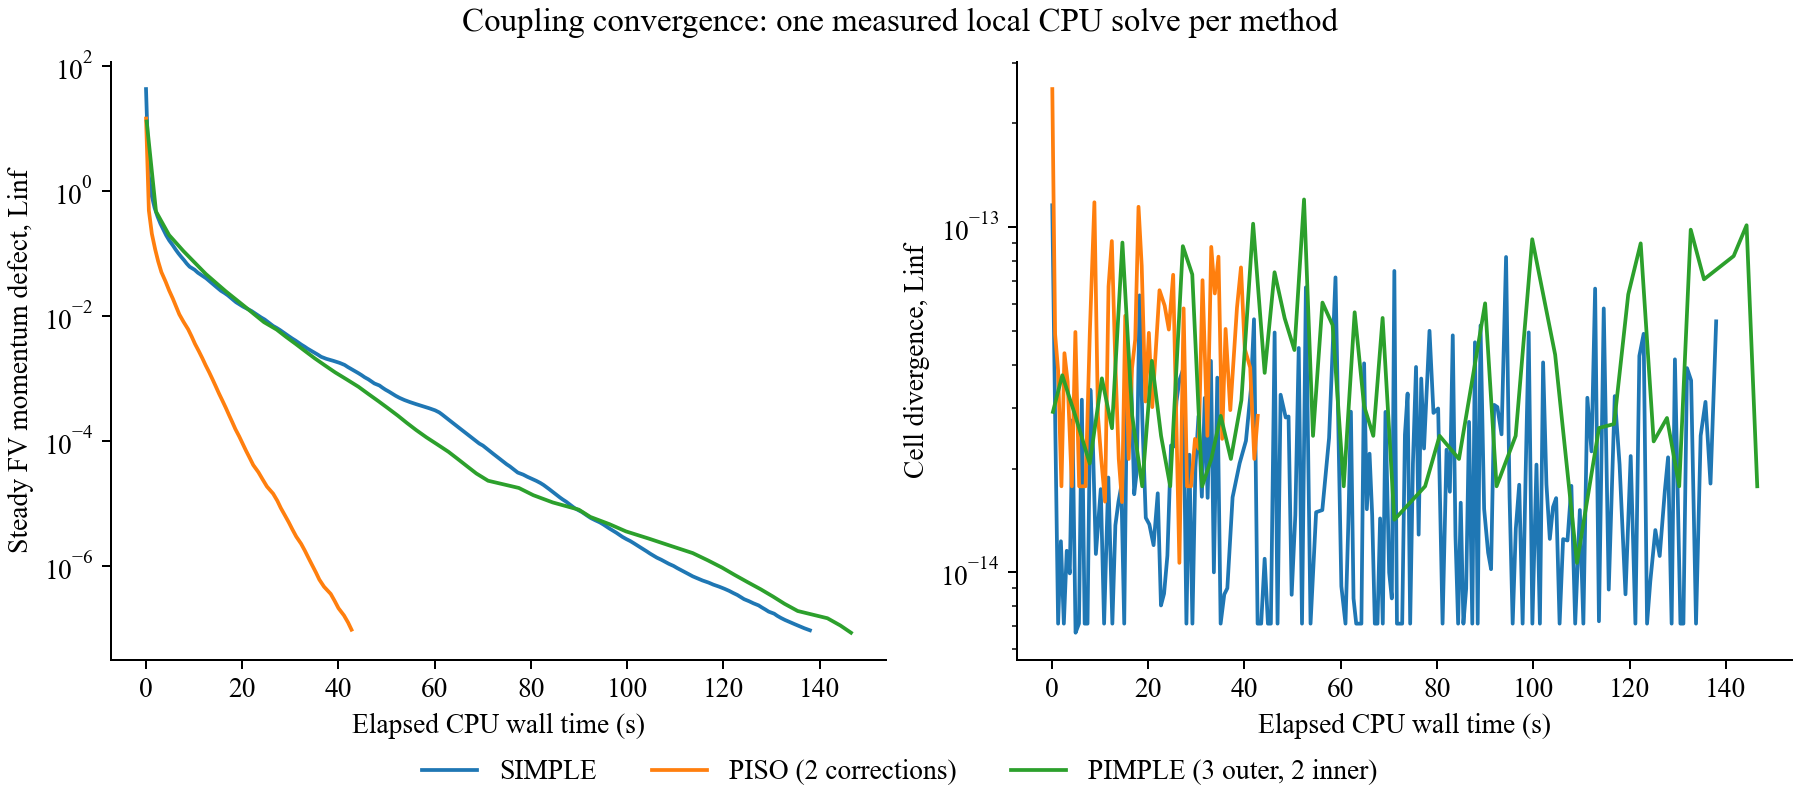

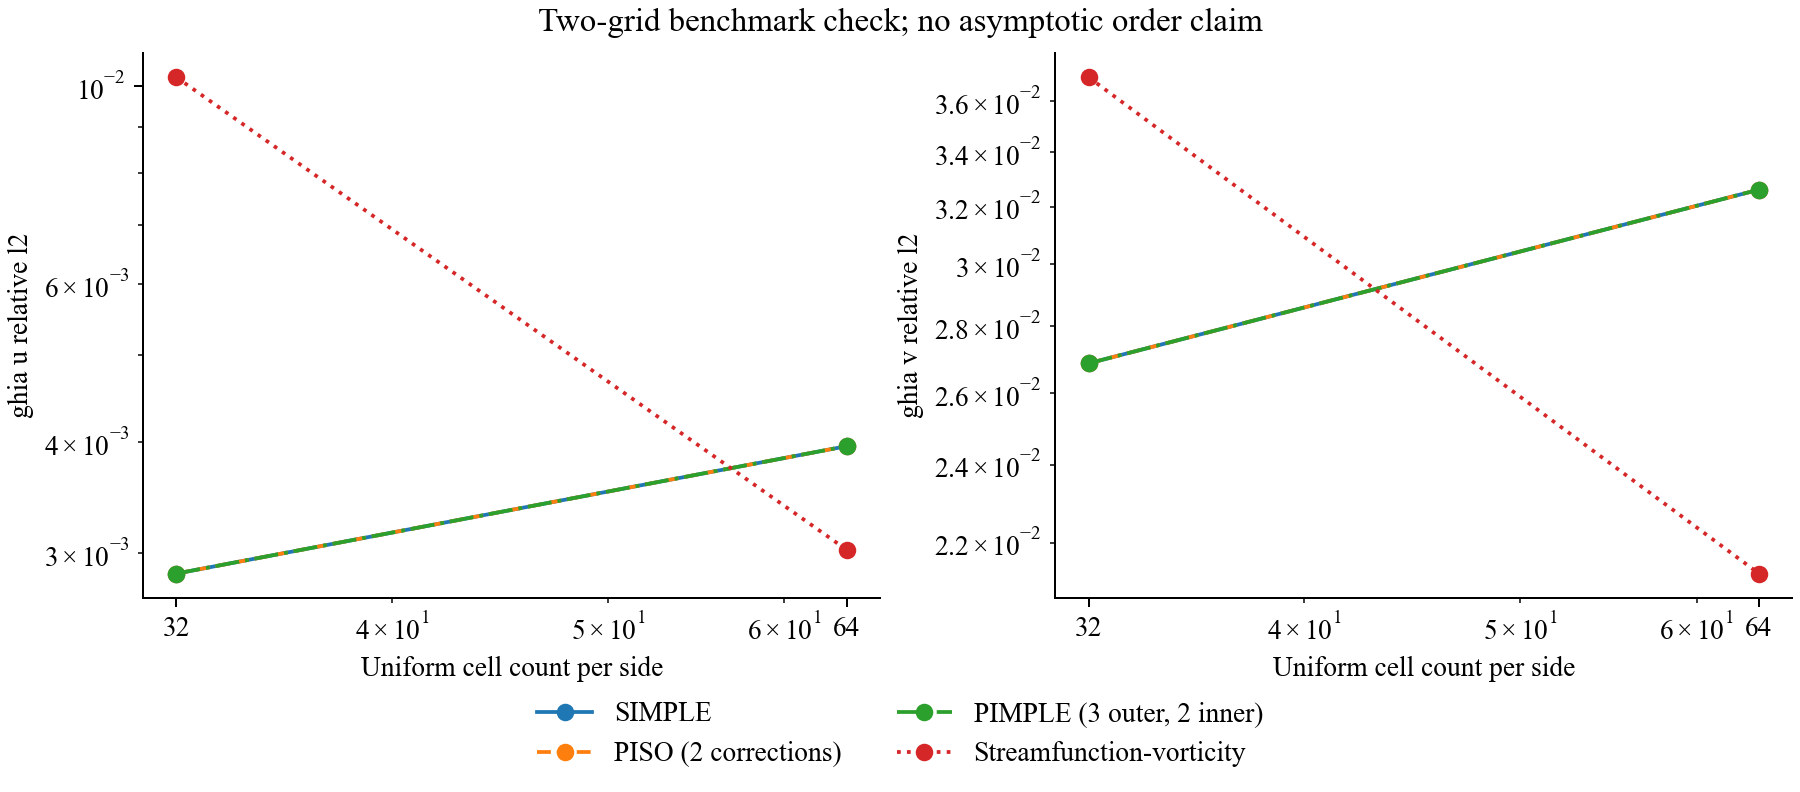

In [2]:
summary = pd.DataFrame([{
    "method": LABELS[r["config"]["method"]], "cells/side": r["config"]["cells"],
    "iterations/steps": r.get("iterations",r.get("steps")), "CPU seconds": r["runtime_seconds"],
    "Ghia u rel L2": r["ghia_u_relative_l2"], "Ghia v rel L2": r["ghia_v_relative_l2"],
    "FV momentum Linf": r.get("momentum_residual_linf",np.nan),
    "FV divergence Linf": r.get("continuity_linf",np.nan),
    "converged": r["converged"]} for r in recorded])
display(summary)
for name in ["centerlines","speed","p","omega","convergence","grid_errors"]:
    display(Image(filename=str(RESULTS / "figures" / (name+".png")),width=950))


## 2. Shared equations and grid
$$\partial_t\mathbf{u}+\nabla\cdot(\mathbf{u}\otimes\mathbf{u})=-\nabla p+Re^{-1}\nabla^2\mathbf{u},\qquad\nabla\cdot\mathbf{u}=0.$$
Unit square, density 1, lid speed 1, viscosity 0.01; impermeable no-slip walls.
Pressure is stored at cell centers, u on vertical faces and v on horizontal faces (MAC).
The lid-corner velocity discontinuity is retained. Tangential wall diffusion uses half-cell distances.

$$Aq=b-Gp,\quad d=1/\operatorname{diag}(A),\quad H(q)=b-\operatorname{offdiag}(A)q,\quad L=-D d G.$$
Here D is conservative cell divergence and G is the face pressure gradient.
Because the cavity is closed, L has a constant nullspace. We pin one cell during the solve and report zero-mean pressure.
Adding a constant to pressure must leave the velocity unchanged.

In [3]:
cfg = CavityConfig(method="simple",cells=32)
n = cfg.cells
print("p shape:",(n,n),"u shape:",(n,n+1),"v shape:",(n+1,n))
L = pressure_matrix(np.ones((n,n-1)),np.ones((n-1,n)),1/n)
print("Constant-pressure nullspace defect:",np.max(np.abs(L @ np.ones(n*n))))
assert np.max(np.abs(L @ np.ones(n*n))) < 1e-10


p shape: (32, 32) u shape: (32, 33) v shape: (33, 32)
Constant-pressure nullspace defect: 0.0


## 3. SIMPLE - steady pressure correction
1. Build and under-relax the steady momentum equations.
2. Solve momentum using the current pressure to obtain tentative face velocity q*.
3. Solve $L p'=-Dq^*$.
4. Correct velocity by the full correction $q=q^*-dGp'$.
5. Update $p\leftarrow p+\alpha_p p'$ and repeat.

Recorded relaxation: alpha_u=0.7 and alpha_p=0.3. The iteration counter is not physical time.
The update size alone is not a reliable stopping residual when relaxation changes.

## 4. PISO - more momentum/pressure corrections within a time step
1. Keep the preceding physical-time velocities immutable.
2. Solve backward-Euler momentum for a tentative velocity.
3. Recompute H using the current velocity, solve $Lp=-D(dH)$, and set $q=d(H-Gp)$.
4. Recompute the off-diagonal momentum contribution and repeat the pressure/velocity correction.

The retained runs use two corrections and dt=0.05. Repeated iterations of one linear Poisson solve are **not** extra PISO corrections.
Backward Euler is first order in time. These retained runs qualify a steady limit, not a transient trajectory.

## 5. PIMPLE - outer momentum loops plus PISO corrections
Within one physical time step, rebuild and solve momentum, then perform the PISO correction loop.
Repeat this outer loop three times, preserving the same old-time fields throughout.

One outer loop reproduces the implemented PISO limit exactly.
Additional outer loops cost more; they can improve nonlinear consistency within a step.
A larger stable dt does not establish accurate startup dynamics.

## Algorithm flowcharts and what the literature compares

The [expanded teaching report](https://github.com/Ehsan-Roohi/FlowMLLab/blob/main/notebooks/week01_2/COMPARISON_AND_TEACHING.md) explains the pressure algebra, actual counters, frozen coefficients and immutable old-time fields. It includes primary paper references, limits of higher-Re claims and a classroom experiment sequence.

### SIMPLE: steady iteration
![SIMPLE control flow](https://raw.githubusercontent.com/Ehsan-Roohi/FlowMLLab/main/results/week01_2_pressure_velocity/flowcharts/simple.png)

### PISO: inner coupling corrections
![PISO control flow](https://raw.githubusercontent.com/Ehsan-Roohi/FlowMLLab/main/results/week01_2_pressure_velocity/flowcharts/piso.png)

### PIMPLE: outer momentum loops and inner corrections
![PIMPLE control flow](https://raw.githubusercontent.com/Ehsan-Roohi/FlowMLLab/main/results/week01_2_pressure_velocity/flowcharts/pimple.png)

### A measured advantage at Re=100
Fifteen startup configurations measure the full nonlinear backward-Euler momentum defect after one physical step. At dt=0.05, PISO with two corrections leaves about 1.11; PIMPLE with three outer/two inner loops leaves about 0.00343, at extra solve cost. All satisfy continuity to pressure-solve precision.

![Within-step coupling experiment](https://raw.githubusercontent.com/Ehsan-Roohi/FlowMLLab/main/results/week01_2_pressure_velocity/figures/coupling_step_study.png)

Extra PISO corrections can improve the frozen matrix defect while plateauing in the full nonlinear defect. PIMPLE rebuilds that matrix. This is **algebraic coupling evidence**, not a physical time-error estimate or proof that larger dt is accurate. [Raw measurements](https://github.com/Ehsan-Roohi/FlowMLLab/blob/main/results/week01_2_pressure_velocity/coupling_step_study.json).

The released solver remains qualified at Re=100. Re=400/1000, a variable lid and a matched temporal-error study are proposed extensions. High-Re spatial under-resolution cannot be fixed solely by adding pressure corrections.

## 6. Fresh student run
The default notebook displays executed results quickly. Set RUN_NEW=True to actually compute one or all algorithms.
Fresh outputs are compared visibly with the retained evidence. For the exact full comparison, run `python qa/run_week01_2.py`.
Avoid ranking one method by its number of iterations: the pressure/momentum solve count and measured elapsed time differ.

In [4]:
RUN_NEW = False
METHOD = "all"  # "simple", "piso", "pimple", or "all"
CELLS = 32
if RUN_NEW:
    chosen = ["simple","piso","pimple"] if METHOD == "all" else [METHOD]
    fresh = [run_cavity(CavityConfig(method=m,cells=CELLS),progress=True) for m in chosen]
    display(pd.DataFrame([{k:r[k] for k in ["converged","iterations","runtime_seconds","momentum_residual_linf","continuity_linf","ghia_u_relative_l2","ghia_v_relative_l2"]} | {"method":r["config"]["method"]} for r in fresh]))
    # Use one fresh result per selected method, preserving other recorded controls.
    active = [r for r in recorded if r["config"]["cells"] != CELLS or r["config"]["method"] not in chosen] + fresh
    for name,fig in figures(active,cells=CELLS).items():
        display(fig); plt.close(fig)
else:
    print("All three algorithms are available; recorded runs are displayed above. Set RUN_NEW=True to recompute.")


All three algorithms are available; recorded runs are displayed above. Set RUN_NEW=True to recompute.


## 7. Interpret the comparison
- Ghia velocity error is distinct from momentum and continuity residuals.
- All three FV methods should approach the same discrete steady solution.
- Agreement with the independent streamfunction formulation is a useful cross-check, not proof that either code is exact.
- Pressure mean must match before differences are compared. Ghia's velocity tables do not validate pressure.
- Two grids show a refinement trend; they do not establish an asymptotic order.
- FV and FD residual definitions differ, so their curves are not presented as the same norm.
- The singular lid corners need consistent boundary treatment; no cosmetic smoothing is applied.

## 8. Exercises
1. Show interior face-flux cancellation in the domain mass budget.
2. Add a constant to pressure and confirm unchanged gradients and velocities.
3. Compare one and two PISO corrections using the physical-step momentum defect.
4. Verify PIMPLE with one outer loop matches PISO.
5. Change SIMPLE relaxation while keeping its final momentum tolerance fixed.
6. Compare upwind and central convection with the same coupling method.
7. Propose a dt-refinement experiment before claiming a PIMPLE speed advantage.

## Attribution
Independent implementation informed by [PySIMPLE](https://github.com/VishalKandala/PySIMPLE), [NIST FiPy's pressure-correction derivation](https://pages.nist.gov/fipy/en/latest/generated/examples.flow.stokesCavity.html), and [OpenFOAM pressure-velocity algorithms](https://www.openfoam.com/documentation/user-guide/6-solving/6.3-solution-and-algorithm-control). The [source notes](README.md) document the additional audited GitHub examples and their limitations. Ghia, Ghia and Shin (1982), DOI: 10.1016/0021-9991(82)90058-4.
